# Heart Disease Prediction

## 1. Data Preprocessing and Cleaning

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

In [10]:
# Loading the dataset and adding column names
cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
        'exang','oldpeak','slope','ca','thal','num']

df = pd.read_csv("../data/heart_disease.csv", names=cols)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nSummary Statistics:")
df.describe()

Shape: (920, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       920 non-null    int64 
 1   sex       920 non-null    int64 
 2   cp        920 non-null    int64 
 3   trestbps  920 non-null    object
 4   chol      920 non-null    object
 5   fbs       920 non-null    object
 6   restecg   920 non-null    object
 7   thalach   920 non-null    object
 8   exang     920 non-null    object
 9   oldpeak   920 non-null    object
 10  slope     920 non-null    object
 11  ca        920 non-null    object
 12  thal      920 non-null    object
 13  num       920 non-null    int64 
dtypes: int64(4), object(10)
memory usage: 100.8+ KB

Summary Statistics:


,age,sex,cp,num
count,920.000000,920.000000,920.000000,920.000000
mean,53.510870,0.789130,3.250000,0.995652
std,9.424685,0.408148,0.930969,1.142693
min,28.000000,0.000000,1.000000,0.000000
25%,47.000000,1.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,1.000000
75%,60.000000,1.000000,4.000000,2.000000
max,77.000000,1.000000,4.000000,4.000000


In [4]:
# Checking for missing data
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [5]:
# Separating numeric and categorical
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Handling missing values using imputation
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [6]:
categorical_features = ["cp", "restecg", "slope", "thal"]

# Appling OneHotEncoder
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df[categorical_features])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features), index=df.index)
df = pd.concat([df.drop(columns=categorical_features), encoded_df], axis=1)

df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,num,cp_2,cp_3,cp_4,restecg_1,restecg_2,slope_2,slope_3,thal_6,thal_7
0,63,1,145,233,1,150,0,2.3,0,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,67,1,160,286,0,108,1,1.5,3,2,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,67,1,120,229,0,129,1,2.6,2,1,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
3,37,1,130,250,0,187,0,3.5,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41,0,130,204,0,172,0,1.4,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


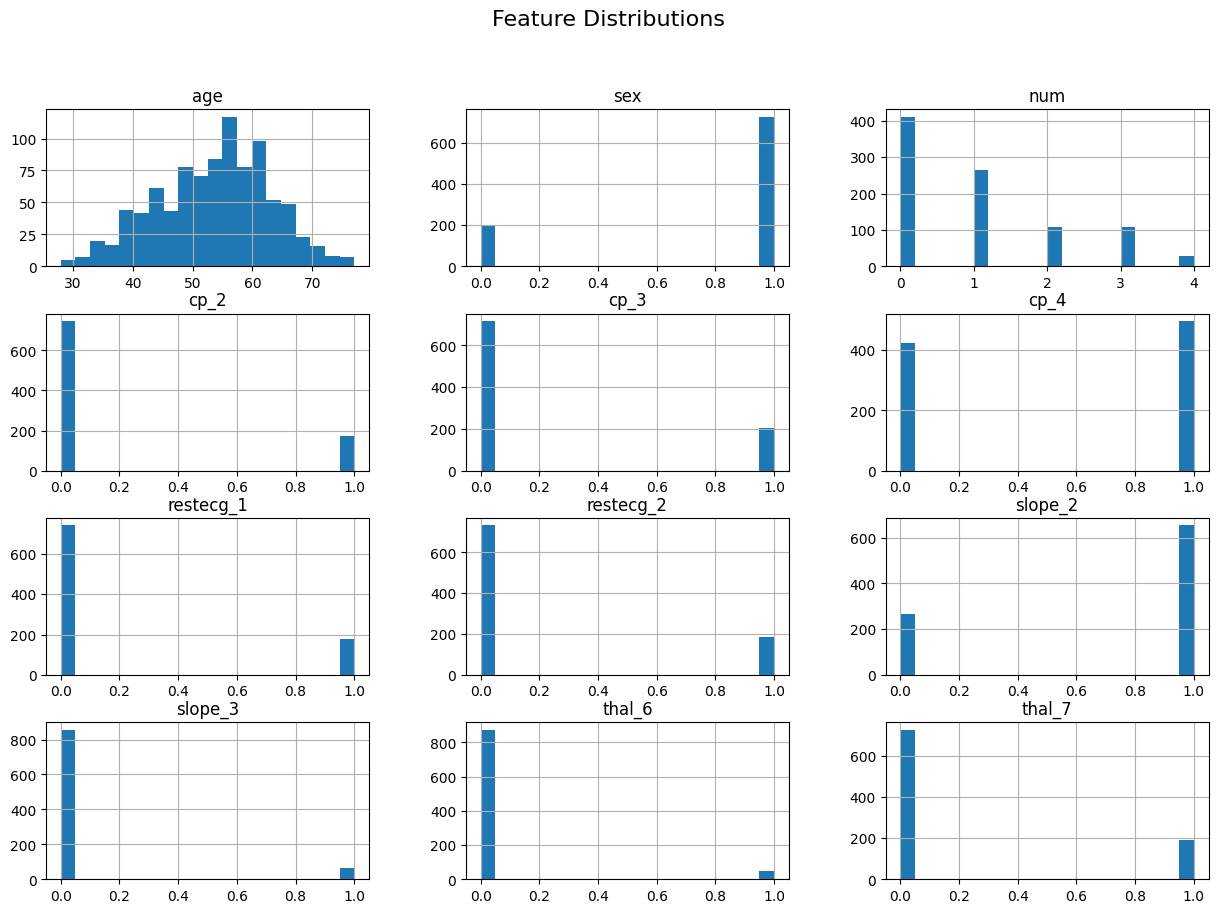

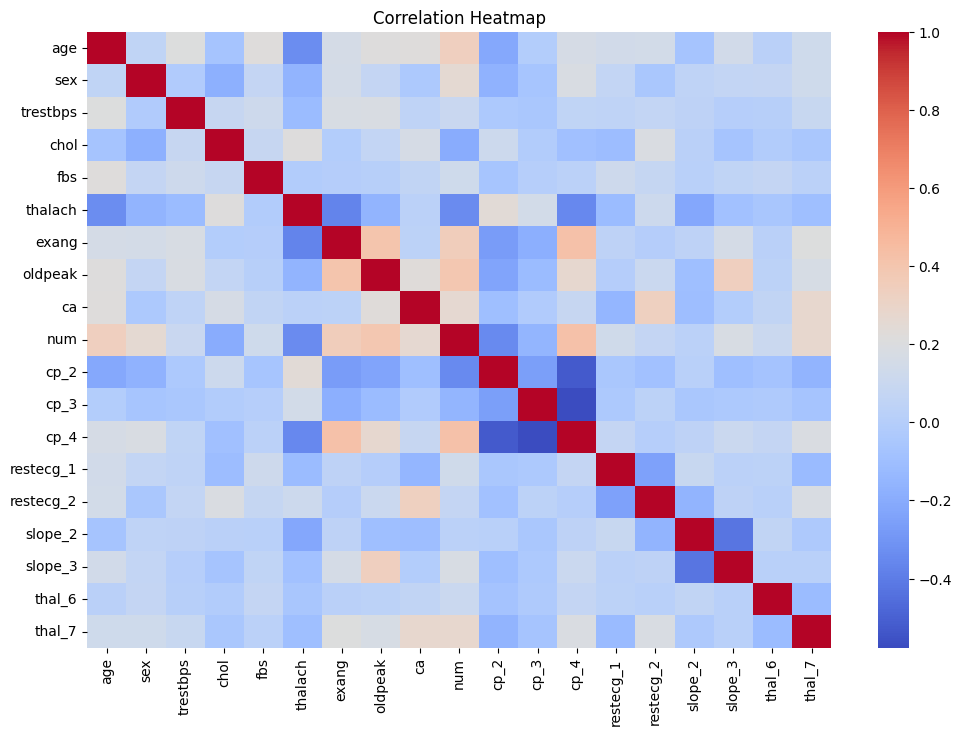

<Figure size 1500x1000 with 0 Axes>

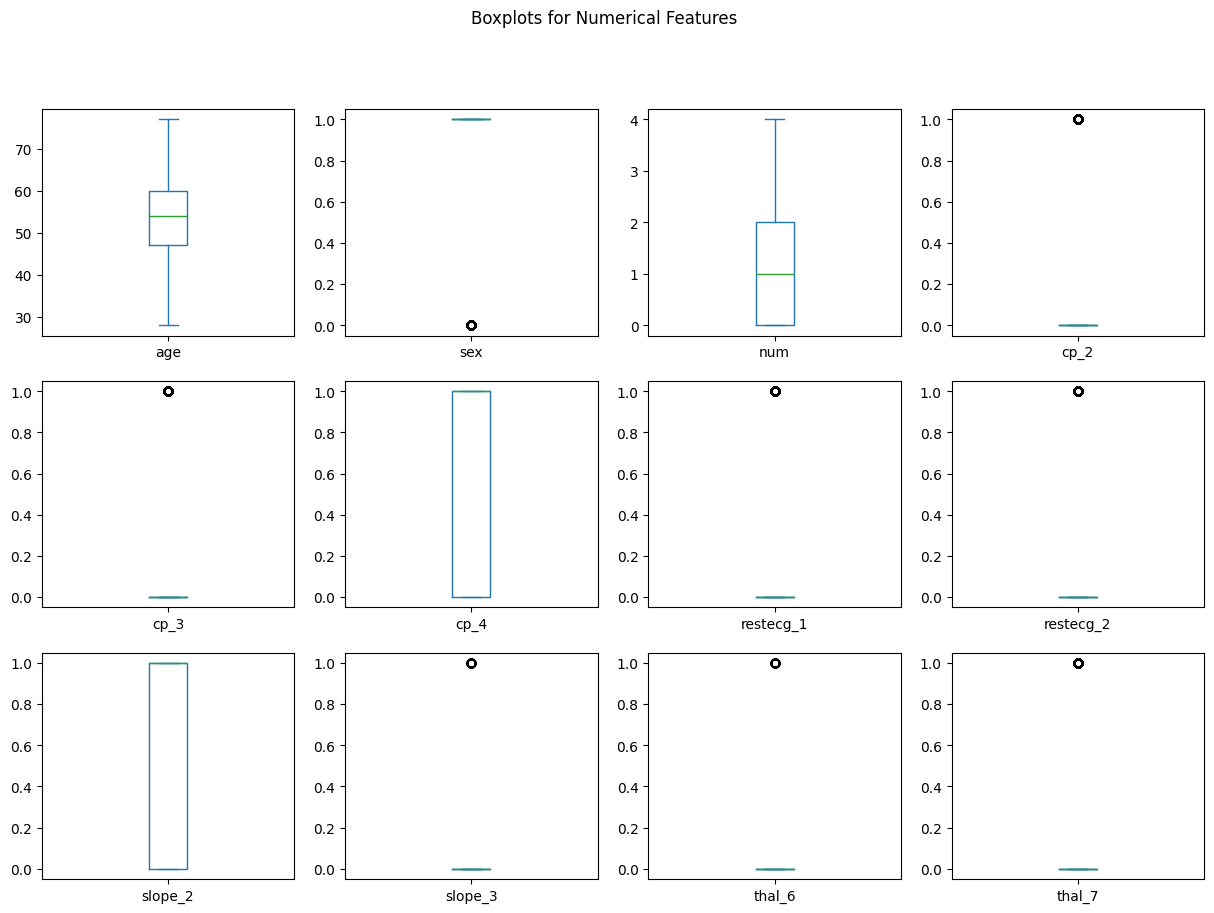

In [7]:
# Histograms
df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Boxplots
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
df[num_cols].plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10), sharex=False, sharey=False)
plt.suptitle("Boxplots for Numerical Features")
plt.show()

In [8]:
# Separate features and target
X = df.drop("num", axis=1)
y = df["num"]

# Scale only the features
num_cols = X.select_dtypes(include=np.number).columns
scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [9]:
df.to_csv("heart_cleaned.csv", index=False)